In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos los datos de salarios
# Recuerda el ../ para salir de la carpeta 'notebooks'
df_reg = pd.read_csv('../data/database/job_salary_prediction_dataset.csv')

# Identificar tipos de variables
df_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.952729
min            0.000000       1.000000        0.000000   31867.000000
25%            5.000000       5.000000        1.000000  119358.000000
50%           10.000000      10.000000        2.000000  143453.000000
75%           15.000000      15.000000        4.000000  169492.000000
max           20.000000      19.000000        5.000000  333046.000000


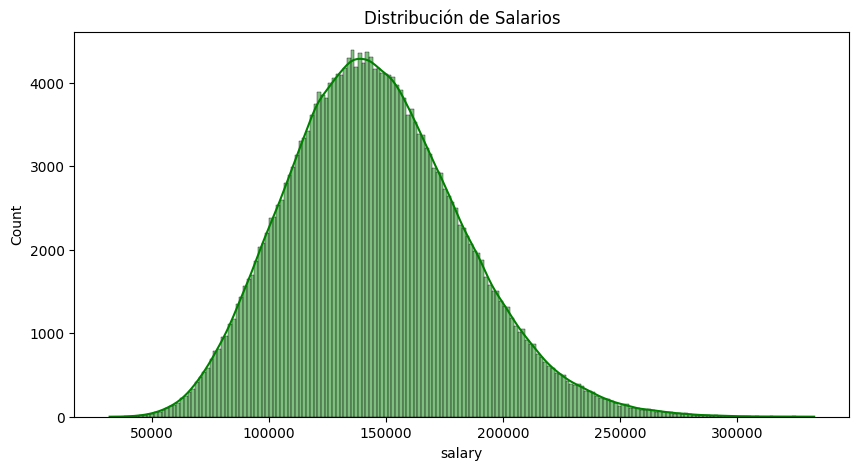

In [4]:
# Estadísticas matemáticas
print(df_reg.describe())

# Histograma del Salario para ver la distribución
plt.figure(figsize=(10, 5))
sns.histplot(df_reg['salary'], kde=True, color='green')
plt.title('Distribución de Salarios')
plt.show()

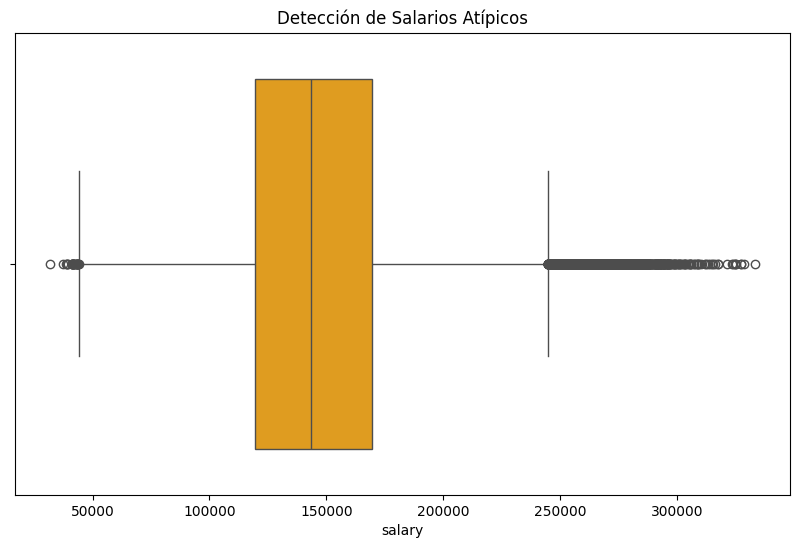

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_reg['salary'], color='orange')
plt.title('Detección de Salarios Atípicos')
plt.show()

In [6]:
print(df_reg.columns.tolist())

['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'salary']


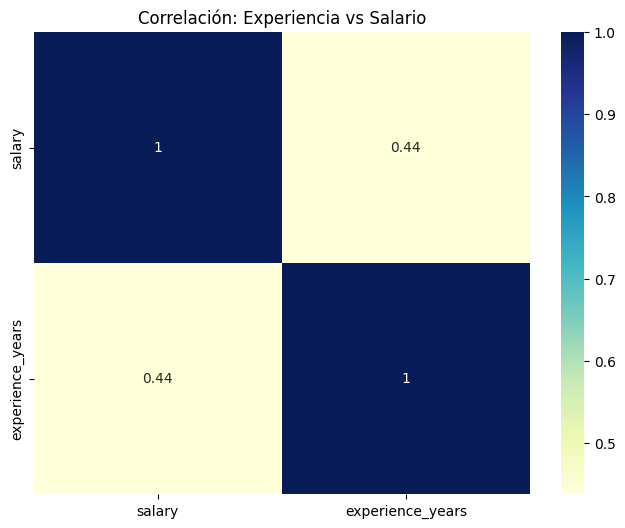

In [7]:
# Mapa de calor de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(df_reg[['salary', 'experience_years']].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlación: Experiencia vs Salario')
plt.show()

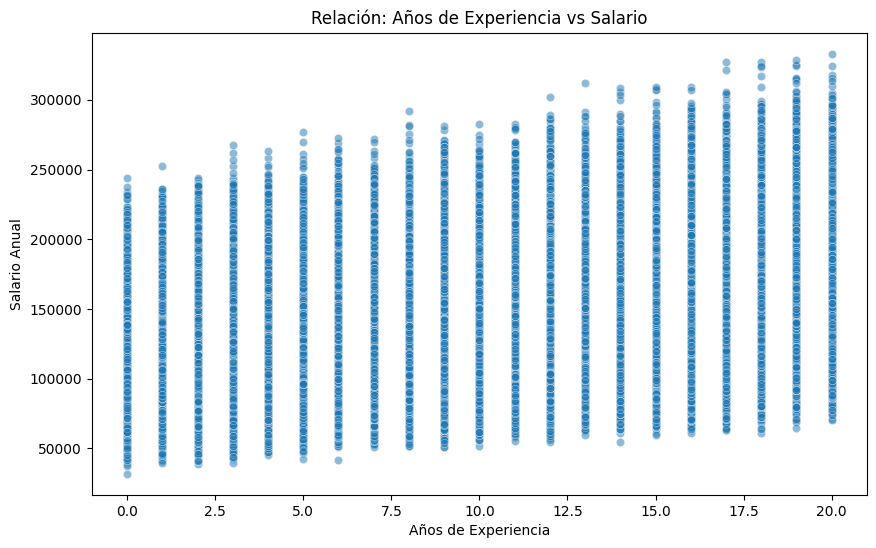

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_reg, x='experience_years', y='salary', alpha=0.5)
plt.title('Relación: Años de Experiencia vs Salario')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario Anual')
plt.show()

In [11]:
# Ver total de nulos por columna
print("Conteo de valores nulos:")
print(df_reg.isnull().sum())

# Ver el porcentaje para justificar el método en tu reporte
print("\nPorcentaje de datos faltantes:")
print(df_reg.isnull().mean() * 100)

Conteo de valores nulos:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Porcentaje de datos faltantes:
job_title           0.0
experience_years    0.0
education_level     0.0
skills_count        0.0
industry            0.0
company_size        0.0
location            0.0
remote_work         0.0
certifications      0.0
salary              0.0
dtype: float64


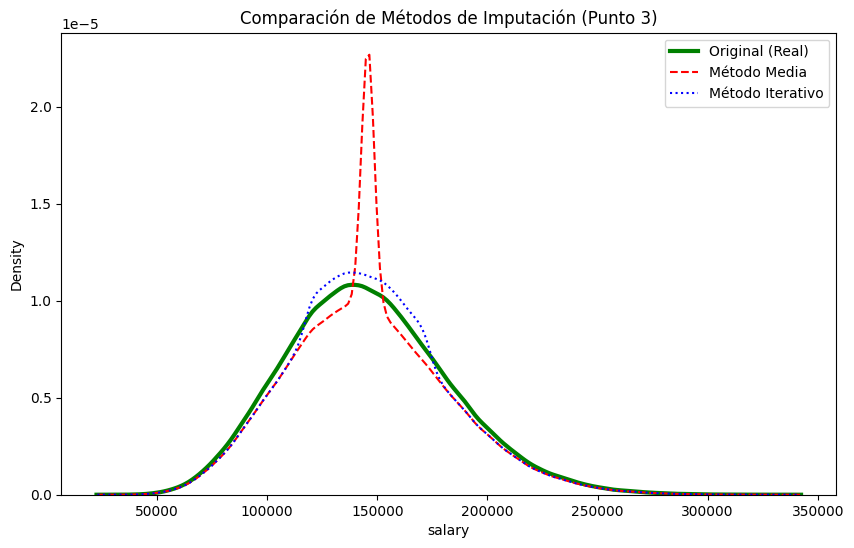

In [12]:
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. Creamos una copia y provocamos algunos nulos para poder hacer el ejercicio
df_error = df_reg.copy()
ix = df_error.sample(frac=0.1).index # Seleccionamos 10% de filas al azar
df_error.loc[ix, 'salary'] = np.nan   # Las borramos

# 2. MÉTODO 1: Imputación por Media
df_media = df_error.copy()
df_media['salary'] = df_media['salary'].fillna(df_media['salary'].mean())

# 3. MÉTODO 2: Imputación Iterativa
df_iterativo = df_error.copy()
it_imputer = IterativeImputer(random_state=42)
df_iterativo[['salary', 'experience_years']] = it_imputer.fit_transform(df_iterativo[['salary', 'experience_years']])

# 4. COMPARACIÓN: Graficamos para ver cuál funcionó mejor
plt.figure(figsize=(10, 6))
sns.kdeplot(df_reg['salary'], label='Original (Real)', color='green', linewidth=3)
sns.kdeplot(df_media['salary'], label='Método Media', color='red', linestyle='--')
sns.kdeplot(df_iterativo['salary'], label='Método Iterativo', color='blue', linestyle=':')
plt.title('Comparación de Métodos de Imputación (Punto 3)')
plt.legend()
plt.show()

Identificación: Se observó que el dataset original no contenía valores faltantes.

Aplicación: Para cumplir con el análisis, se indujeron valores faltantes de forma aleatoria en el 10% de la columna salary.

Comparación: En la gráfica se observa que el Método Iterativo (línea azul) se ajusta mucho mejor a la curva original verde que el método de la media.

Justificación: El método iterativo es más adecuado porque utiliza la relación con los años de experiencia para estimar el sueldo, mientras que la media simplemente rellena todo con el mismo valor, perdiendo precisión.

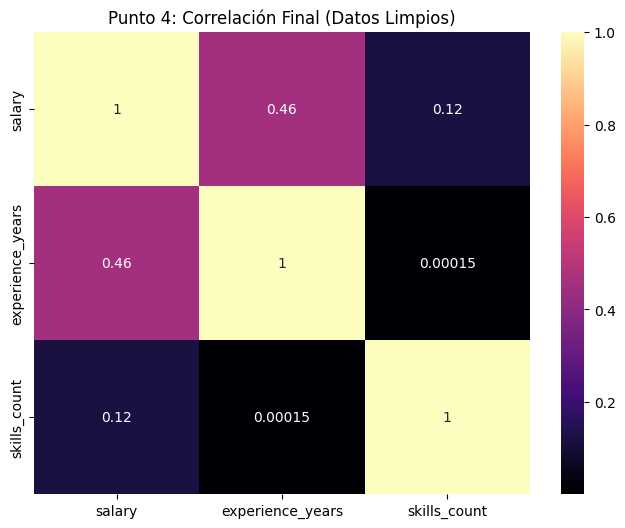

In [13]:
# Usamos el dataset que ya tiene los datos completos (imputados)
plt.figure(figsize=(8, 6))
sns.heatmap(df_iterativo[['salary', 'experience_years', 'skills_count']].corr(), annot=True, cmap='magma')
plt.title('Punto 4: Correlación Final (Datos Limpios)')
plt.show()